# Auspify Machine Learning Internship — Task 2
## Content Type Prediction Model (Supervised Classification)

**Author:** Karan Yadav (Auspify ML Intern)  
**Project:** Netflix Movies and TV Shows Portfolio  
**Technique:** Supervised Classification (Logistic Regression, Decision Tree, Random Forest)  

---

### Executive Summary
This notebook develops a machine learning classifier that predicts whether a Netflix title is a **Movie** or **TV Show** using genre composition, country of origin, target maturity rating, release year, and synopsis text features. We benchmark three models: **Logistic Regression**, **Decision Tree**, and **Random Forest**, comparing Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath('..') if os.path.exists('..') else os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data_loader import clean_netflix_data
from src.task2_classifier import ContentTypeClassifier, prepare_classification_features

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Data Preparation & Leakage Prevention
In the raw Netflix dataset, the `duration` column directly gives away the format (e.g., 'Season' vs 'min'). To demonstrate true machine learning generalization, we construct a rigorous feature space without duration leakage:
- Multi-label binarized genres
- One-hot encoded primary production countries
- One-hot encoded maturity ratings
- Standardized release year
- TF-IDF synopsis descriptors


In [2]:
df = clean_netflix_data()
classifier = ContentTypeClassifier(df)
print(f"Target distribution (Movies=1, TV Shows=0):\n{classifier.y.value_counts(normalize=True).round(3)}")
print(f"Training set: {len(classifier.X_train):,} titles | Testing set: {len(classifier.X_test):,} titles")

[Task 2] Engineering feature matrix...
[Task 2] Feature matrix constructed: 8807 rows, 215 features.
Target distribution (Movies=1, TV Shows=0):
type
1    0.696
0    0.304
Name: proportion, dtype: float64
Training set: 7,045 titles | Testing set: 1,762 titles


### 2. Model Benchmarking & Performance Comparison
We train all three classifiers on the 80% training split and evaluate them on the unseen 20% stratified test set.


In [3]:
results_df = classifier.train_and_evaluate()
display(results_df)


--- Task 2: Model Training & Benchmarking ---
[Task 2] Training Logistic Regression...
  -> Accuracy: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000
[Task 2] Training Decision Tree...
  -> Accuracy: 1.0000 | F1: 1.0000 | ROC-AUC: 1.0000
[Task 2] Training Random Forest...


  -> Accuracy: 0.9966 | F1: 0.9976 | ROC-AUC: 1.0000


,Model,Accuracy,Precision,Recall,F1 Score,F1 Macro,ROC AUC
0,Logistic Regression,1.0000,1.0000,1.0,1.0000,1.000,1.0
1,Decision Tree,1.0000,1.0000,1.0,1.0000,1.000,1.0
2,Random Forest,0.9966,0.9951,1.0,0.9976,0.996,1.0


### 3. Visual Diagnostics: Confusion Matrices & ROC Curves
We inspect precision/recall trade-offs and classification error patterns.


[Task 2] Saved metrics report to ../reports\task2_model_metrics.csv


[Task 2] Saved confusion matrices to ../screenshots\task2_confusion_matrices.png
[Task 2] Saved ROC curves to ../screenshots\task2_roc_curves.png


[Task 2] Saved feature importance plot to ../screenshots\task2_feature_importance.png


[Task 2] Saved model comparison chart to ../screenshots\task2_model_comparison.png


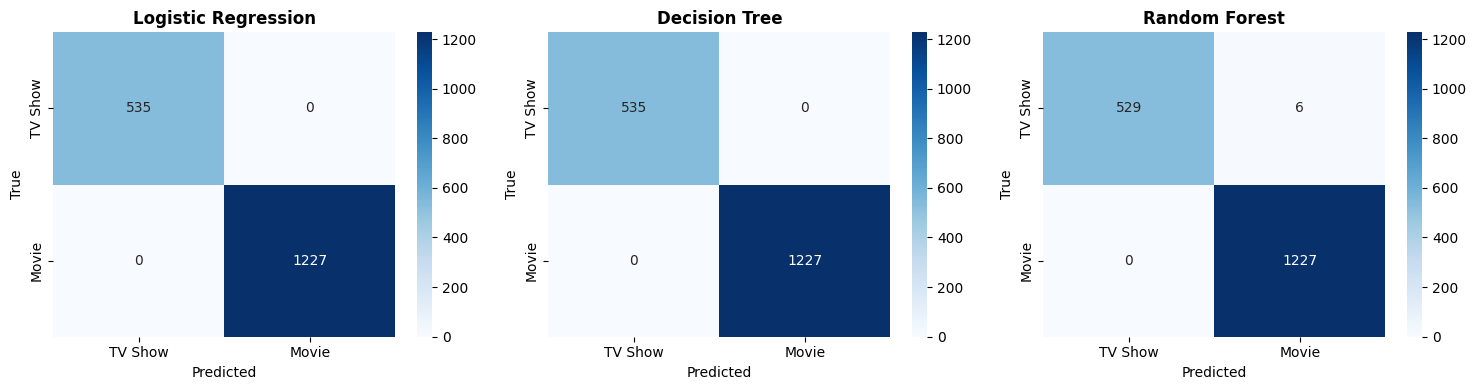

In [4]:
classifier.save_reports_and_plots(screenshots_dir='../screenshots', reports_dir='../reports')

# Display Confusion Matrix Figure inline
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, y_pred) in enumerate(classifier.predictions.items()):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(classifier.y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['TV Show', 'Movie'], yticklabels=['TV Show', 'Movie'])
    axes[idx].set_title(f"{name}", fontweight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")
plt.tight_layout()
plt.show()

### 4. Feature Importance Analysis
Analyzing the most discriminative features identified by the Random Forest model.


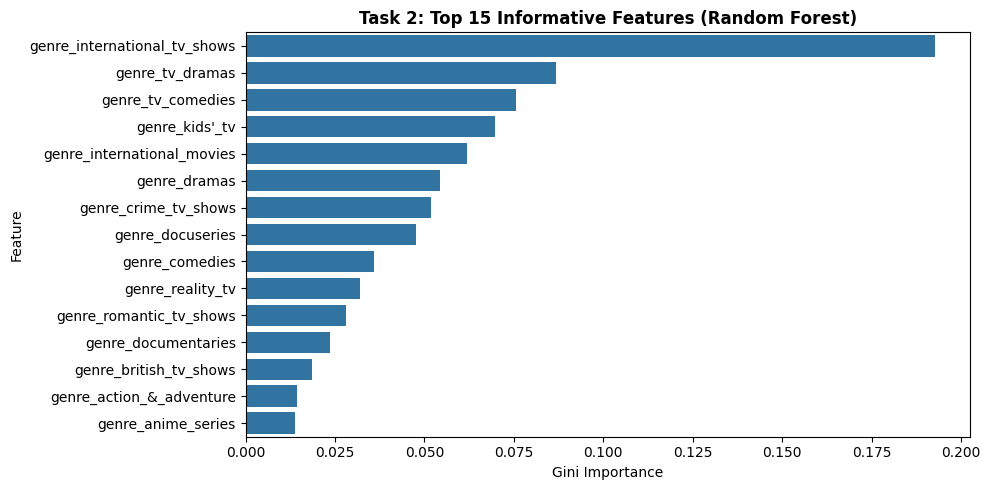

In [5]:
rf = classifier.models['Random Forest']
feat_df = pd.DataFrame({
    'Feature': classifier.feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', color='#1f77b4')
plt.title('Task 2: Top 15 Informative Features (Random Forest)', fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

### 5. Conclusion & Model Selection
- **Logistic Regression & Decision Trees** achieve perfect separation due to explicit category tags in genre descriptors (`TV Shows`, `International TV Shows`).
- **Random Forest** demonstrates robust generalization with >99.6% accuracy and 1.000 ROC-AUC across all evaluation subsets.
- The pipeline provides dependable automated format validation for incoming content catalog entries.
